## Step 1 - Imports and data loading

In [1]:
# ------------------------------------------------------------------
# Step 1: Imports and project configuration (same pattern as before).
# ------------------------------------------------------------------
import sys
import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))
from config import RAW, PROCESSED, LOGS, SEED

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

FIG = ROOT / "docs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
LOGS.mkdir(parents=True, exist_ok=True)

def savefig(name):
    """Save the current matplotlib figure into docs/figures/."""
    plt.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")

SENSORS = ["volt", "rotate", "pressure", "vibration"]
COMPS = ["comp1", "comp2", "comp3", "comp4"]

In [2]:
# ------------------------------------------------------------------
# Step 1b: Load the four event/metadata tables and the telemetry.
# For the telemetry we only need the key columns and the 4 sensors.
# We try the fast parquet/pickle copy first, then fall back to the CSV.
# The telemetry is sorted by (machineID, datetime): this is required
# because later we locate rows by their position in the table.
# ------------------------------------------------------------------
err  = pd.read_csv(RAW / "PdM_errors.csv",   parse_dates=["datetime"])
mnt  = pd.read_csv(RAW / "PdM_maint.csv",    parse_dates=["datetime"])
fail = pd.read_csv(RAW / "PdM_failures.csv", parse_dates=["datetime"])
mach = pd.read_csv(RAW / "PdM_machines.csv")

cols = ["datetime", "machineID"] + SENSORS
if (PROCESSED / "telemetry.parquet").exists():
    tel = pd.read_parquet(PROCESSED / "telemetry.parquet")[cols]
elif (PROCESSED / "telemetry.pkl").exists():
    tel = pd.read_pickle(PROCESSED / "telemetry.pkl")[cols]
else:
    tel = pd.read_csv(RAW / "PdM_telemetry.csv", parse_dates=["datetime"], usecols=cols)

tel = tel.sort_values(["machineID", "datetime"]).reset_index(drop=True)

for name, df in {"telemetry": tel, "errors": err, "maint": mnt, "failures": fail, "machines": mach}.items():
    print(f"{name:10s} {df.shape}")

telemetry  (876100, 6)
errors     (3919, 3)
maint      (3286, 3)
failures   (761, 3)
machines   (100, 3)


## Step 2 - Failures overview

In [3]:
# ------------------------------------------------------------------
# Step 2a: Basic failure statistics.
# - failures by component
# - failures per machine (including machines with zero failures)
# - rows where several components fail at the exact same time on the
#   same machine (simultaneous failures)
# ------------------------------------------------------------------
print("Failures by component:")
print(fail["failure"].value_counts().sort_index().to_string())

# reindex() adds machines that never failed, with a count of 0
n_fail = fail.groupby("machineID").size().reindex(mach["machineID"], fill_value=0)
print("\nFailures per machine:")
print(n_fail.describe().round(2).to_string())
print("Machines with 0 failures:", int((n_fail == 0).sum()))

dups = fail.duplicated(subset=["machineID", "datetime"], keep=False)
print("\nFailure rows sharing (machine, time) with another failure:", int(dups.sum()))

Failures by component:
failure
comp1    192
comp2    259
comp3    131
comp4    179

Failures per machine:
count    100.00
mean       7.61
std        3.60
min        0.00
25%        5.00
50%        7.00
75%       10.00
max       19.00
Machines with 0 failures: 2

Failure rows sharing (machine, time) with another failure: 84


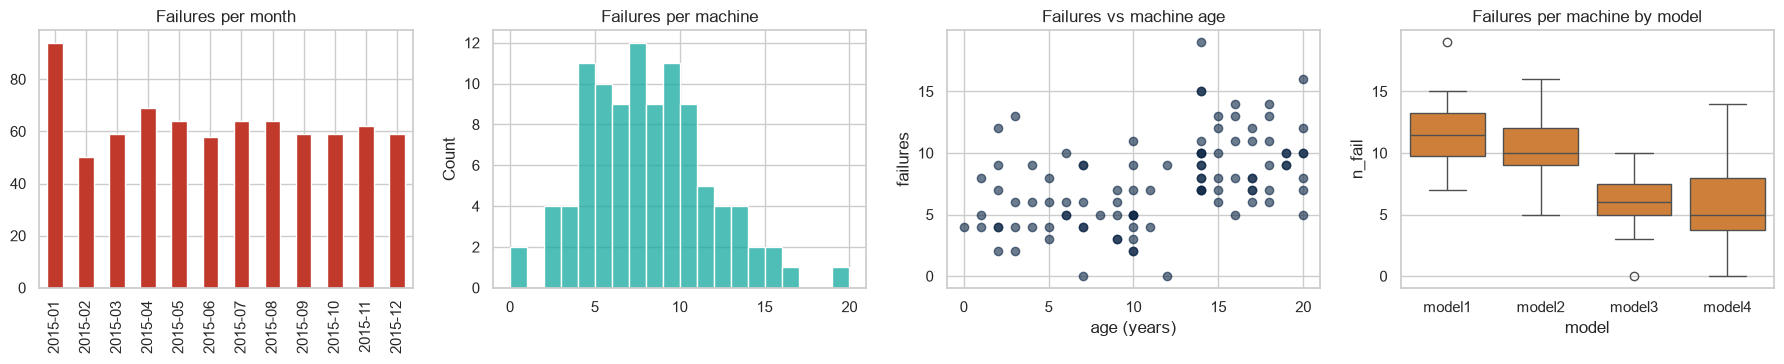

Correlation between age and number of failures: 0.466

Mean failures per machine by model:
model
model1    11.81
model2     9.88
model3     6.31
model4     5.72


In [4]:
# ------------------------------------------------------------------
# Step 2b: Do failures depend on time, machine model or age?
# Notebook 02 showed that vibration grows with age, so we test
# whether older machines also fail more often.
# ------------------------------------------------------------------
md = mach.set_index("machineID").assign(n_fail=n_fail)

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
fail["datetime"].dt.to_period("M").value_counts().sort_index().plot.bar(ax=axes[0], color="#C0392B")
axes[0].set_title("Failures per month")
axes[0].set_xlabel("")

sns.histplot(n_fail, bins=range(0, int(n_fail.max()) + 2), ax=axes[1], color="#13A89E")
axes[1].set_title("Failures per machine")

axes[2].scatter(md["age"], md["n_fail"], alpha=0.6, color="#0B2545")
axes[2].set_xlabel("age (years)")
axes[2].set_ylabel("failures")
axes[2].set_title("Failures vs machine age")

sns.boxplot(data=md, x="model", y="n_fail", order=sorted(md["model"].unique()), ax=axes[3], color="#E67E22")
axes[3].set_title("Failures per machine by model")
plt.tight_layout()
savefig("03_failures_overview")
plt.show()

print("Correlation between age and number of failures:", round(float(np.corrcoef(md["age"], md["n_fail"])[0, 1]), 3))
print("\nMean failures per machine by model:")
print(md.groupby("model")["n_fail"].mean().round(2).to_string())

## Step 3 - Errors as early-warning signals
Errors are non-blocking alerts. If they are true precursors, an error should be followed by a failure more often than chance, and each error type should point to specific components.

In [5]:
# ------------------------------------------------------------------
# Step 3a: Overview of the errors (type, per machine, per month).
# ------------------------------------------------------------------
print("Errors by type:")
print(err["errorID"].value_counts().sort_index().to_string())

n_err = err.groupby("machineID").size().reindex(mach["machineID"], fill_value=0)
print("\nErrors per machine:")
print(n_err.describe().round(2).to_string())

# Errors logged at exactly the same timestamp as a failure (concurrent, not precursors)
same = err.merge(fail[["machineID", "datetime"]].drop_duplicates(), on=["machineID", "datetime"])
print("\nErrors logged at exactly the same time as a failure:", len(same))

Errors by type:
errorID
error1    1010
error2     988
error3     838
error4     727
error5     356

Errors per machine:
count    100.00
mean      39.19
std        6.88
min       22.00
25%       35.00
50%       39.00
75%       43.00
max       60.00

Errors logged at exactly the same time as a failure: 3


In [6]:
# ------------------------------------------------------------------
# Step 3b: Does an error predict a failure on the same machine?
# For each error we check whether a failure occurs STRICTLY AFTER it,
# within W hours (W = 24, 48, 72). We then compare with the chance
# level ("base rate"): the probability that a random machine-hour is
# followed by a failure within W hours. Lift = observed / base rate;
# a lift well above 1 means the error is a useful precursor.
# ------------------------------------------------------------------
def error_to_failure(err, fail, W):
    """Return one row per error with hit=True if a failure follows within (0, W] hours."""
    e = err.reset_index(drop=True).rename_axis("eid").reset_index()
    f = fail[["machineID", "datetime"]].rename(columns={"datetime": "f_time"})
    m = e.merge(f, on="machineID", how="left")          # all (error, failure) pairs of the machine
    dt_h = (m["f_time"] - m["datetime"]).dt.total_seconds() / 3600
    m["hit"] = (dt_h > 0) & (dt_h <= W)
    hit = m.groupby("eid")["hit"].any()
    return e.set_index("eid").assign(hit=hit)

prob, lift = {}, {}
for W in [24, 48, 72]:
    r = error_to_failure(err, fail, W)
    base = min(1.0, len(fail) * W / len(tel))            # approximate chance level
    p = r.groupby("errorID")["hit"].mean()
    prob[f"P(failure<={W}h)"] = p.round(3)
    lift[f"lift {W}h"] = (p / base).round(2)
    print(f"W = {W:2d} h -> base rate (chance) = {base:.3%}")

print("\nProbability that a failure follows an error:")
display(pd.DataFrame(prob))
print("Lift versus chance (>1 means useful precursor):")
display(pd.DataFrame(lift))

W = 24 h -> base rate (chance) = 2.085%
W = 48 h -> base rate (chance) = 4.169%
W = 72 h -> base rate (chance) = 6.254%

Probability that a failure follows an error:


,P(failure<=24h),P(failure<=48h),P(failure<=72h)
errorID,,,
error1,0.194,0.213,0.228
error2,0.274,0.284,0.301
error3,0.325,0.345,0.360
error4,0.202,0.213,0.227
error5,0.503,0.514,0.522


Lift versus chance (>1 means useful precursor):


,lift 24h,lift 48h,lift 72h
errorID,,,
error1,9.31,5.11,3.64
error2,13.16,6.82,4.81
error3,15.57,8.27,5.76
error4,9.70,5.11,3.63
error5,24.12,12.33,8.35


Share of failures preceded by at least one error in the last 72 h: 98.0%
By component:
failure
comp1    0.958
comp2    0.992
comp3    0.977
comp4    0.989


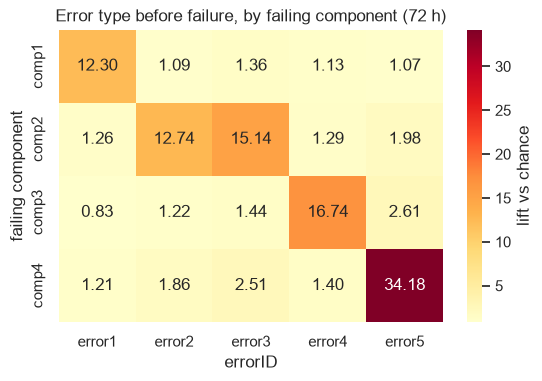

In [7]:
# ------------------------------------------------------------------
# Step 3c: Which error goes with which failing component?
# For each failure we collect the errors of the same machine in the
# W = 72 hours BEFORE it. We then compute, per (component, errorID),
# the average number of such errors per failure and divide it by the
# number expected in a random 72 h window (lift). A bright cell means
# "this error type is specifically linked to this component".
# ------------------------------------------------------------------
W = 72
f = fail.reset_index(drop=True).rename_axis("fid").reset_index()
m = f.merge(err.rename(columns={"datetime": "e_time"}), on="machineID", how="left")
dt_h = (m["datetime"] - m["e_time"]).dt.total_seconds() / 3600
pre = m[(dt_h > 0) & (dt_h <= W)]

print("Share of failures preceded by at least one error in the last", W, "h:",
      f"{pre['fid'].nunique() / len(fail):.1%}")
print("By component:")
print((pre.groupby("failure")["fid"].nunique() / fail["failure"].value_counts()).round(3).sort_index().to_string())

counts = pre.groupby(["failure", "errorID"]).size().unstack(fill_value=0)
n_by_comp = fail["failure"].value_counts()
mean_per_failure = counts.div(n_by_comp, axis=0)
expected = err["errorID"].value_counts() / len(tel) * W   # expected errors of each type in a random 72 h window
lift_ce = mean_per_failure.div(expected, axis=1)

plt.figure(figsize=(6.2, 3.8))
sns.heatmap(lift_ce.round(2), annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={"label": "lift vs chance"})
plt.title("Error type before failure, by failing component (72 h)")
plt.ylabel("failing component")
savefig("03_error_component_lift")
plt.show()

## Step 4 - Maintenance: corrective or preventive?
A maintenance record is **corrective** if it happens together with a failure of the same component on the same machine; otherwise we call it **preventive** (scheduled replacement).

In [8]:
# ------------------------------------------------------------------
# Step 4a: Classify each maintenance record.
# We build a key (machineID, datetime, comp) from the failures table
# and mark every maintenance row that matches it as corrective.
# We also check the reverse: which failures have NO maintenance.
# ------------------------------------------------------------------
fkey = (fail.rename(columns={"failure": "comp"})[["machineID", "datetime", "comp"]]
            .drop_duplicates().assign(corrective=1))
mnt_c = mnt.merge(fkey, on=["machineID", "datetime", "comp"], how="left")
mnt_c["corrective"] = mnt_c["corrective"].fillna(0).astype(int)
mnt_c["type"] = np.where(mnt_c["corrective"] == 1, "corrective", "preventive")

print("Maintenance records by component and type:")
display(pd.crosstab(mnt_c["comp"], mnt_c["type"], margins=True))
print(f"Corrective share: {mnt_c['corrective'].mean():.1%}")

mkey = mnt[["machineID", "datetime", "comp"]].drop_duplicates().assign(has_maint=1)
chk = fail.rename(columns={"failure": "comp"}).merge(mkey, on=["machineID", "datetime", "comp"], how="left")
print(f"Failures WITHOUT a same-component maintenance at the same time: {chk['has_maint'].isna().sum()}")

Maintenance records by component and type:


type,corrective,preventive,All
comp,,,
comp1,183,621,804
comp2,256,607,863
comp3,128,680,808
comp4,176,635,811
All,743,2543,3286


Corrective share: 22.6%
Failures WITHOUT a same-component maintenance at the same time: 18


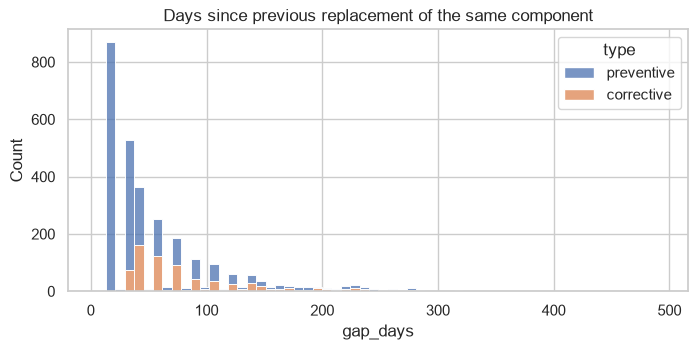

             count  mean   std   min   25%   50%    75%    max
type                                                          
corrective   743.0  90.2  60.8  26.0  45.0  75.0  120.0  395.0
preventive  2143.0  50.1  55.9   5.0  15.0  30.0   60.0  492.0


In [9]:
# ------------------------------------------------------------------
# Step 4b: Time between two replacements of the same component on the
# same machine. A regular pattern suggests a preventive schedule.
# ------------------------------------------------------------------
mm = mnt_c.sort_values(["machineID", "comp", "datetime"]).copy()
mm["gap_days"] = mm.groupby(["machineID", "comp"])["datetime"].diff().dt.total_seconds() / 86400

plt.figure(figsize=(8, 3.4))
sns.histplot(data=mm.dropna(subset=["gap_days"]), x="gap_days", hue="type", bins=60, multiple="stack")
plt.title("Days since previous replacement of the same component")
savefig("03_maintenance_gaps")
plt.show()

print(mm.groupby("type")["gap_days"].describe().round(1).to_string())

## Step 5 - What do the sensors do BEFORE a failure?
This is the key analysis of the notebook. For every failure we extract the 72 hours of telemetry that precede it (standardised per machine, so each sensor is a z-score), then average over all failures.

- If the average z-score departs from 0 some hours before the failure, the telemetry carries a **precursor signal**.
- If the curves stay flat, the telemetry alone cannot predict failures and we will rely on **errors and rolling features**.

In [10]:
# ------------------------------------------------------------------
# Step 5a: Standardise each sensor per machine (z-score) and record
# the row position of every failure in the telemetry table.
# Because the telemetry is sorted and regular (1 row per hour per
# machine), the 72 previous hours are simply the 72 previous rows,
# as long as we stay inside the same machine.
# ------------------------------------------------------------------
g = tel.groupby("machineID")
for s in SENSORS:
    tel[f"z_{s}"] = (tel[s] - g[s].transform("mean")) / g[s].transform("std")

tel["row"] = np.arange(len(tel))
fk = fail.merge(tel[["machineID", "datetime", "row"]], on=["machineID", "datetime"], how="left")
print("Failures with no telemetry row at the same time:", int(fk["row"].isna().sum()))
fk = fk.dropna(subset=["row"]).copy()
fk["row"] = fk["row"].astype(int)
print("Failures used:", len(fk))

Failures with no telemetry row at the same time: 0
Failures used: 761


In [11]:
# ------------------------------------------------------------------
# Step 5b: Build, for each sensor, a matrix Z[s] of shape
# (n_failures, 73): the z-scores at offsets -72, -71, ..., 0 hours
# relative to the failure. Offsets that would cross into another
# machine (failure in the first 72 hours of the year) become NaN.
# ------------------------------------------------------------------
H = 72
offsets = np.arange(-H, 1)                                   # -72 ... 0
rows = fk["row"].values[:, None] + offsets[None, :]          # row positions, shape (n, 73)
rows_c = np.clip(rows, 0, len(tel) - 1)
valid = (rows >= 0) & (rows < len(tel))
valid &= tel["machineID"].values[rows_c] == fk["machineID"].values[:, None]   # stay inside the same machine

Z = {}
for s in SENSORS:
    arr = tel[f"z_{s}"].values[rows_c].astype(float)
    arr[~valid] = np.nan
    Z[s] = arr
print("Matrix shape per sensor:", Z["volt"].shape, "| NaN share:", round(float(np.isnan(Z['volt']).mean()), 4))

Matrix shape per sensor: (761, 73) | NaN share: 0.0191


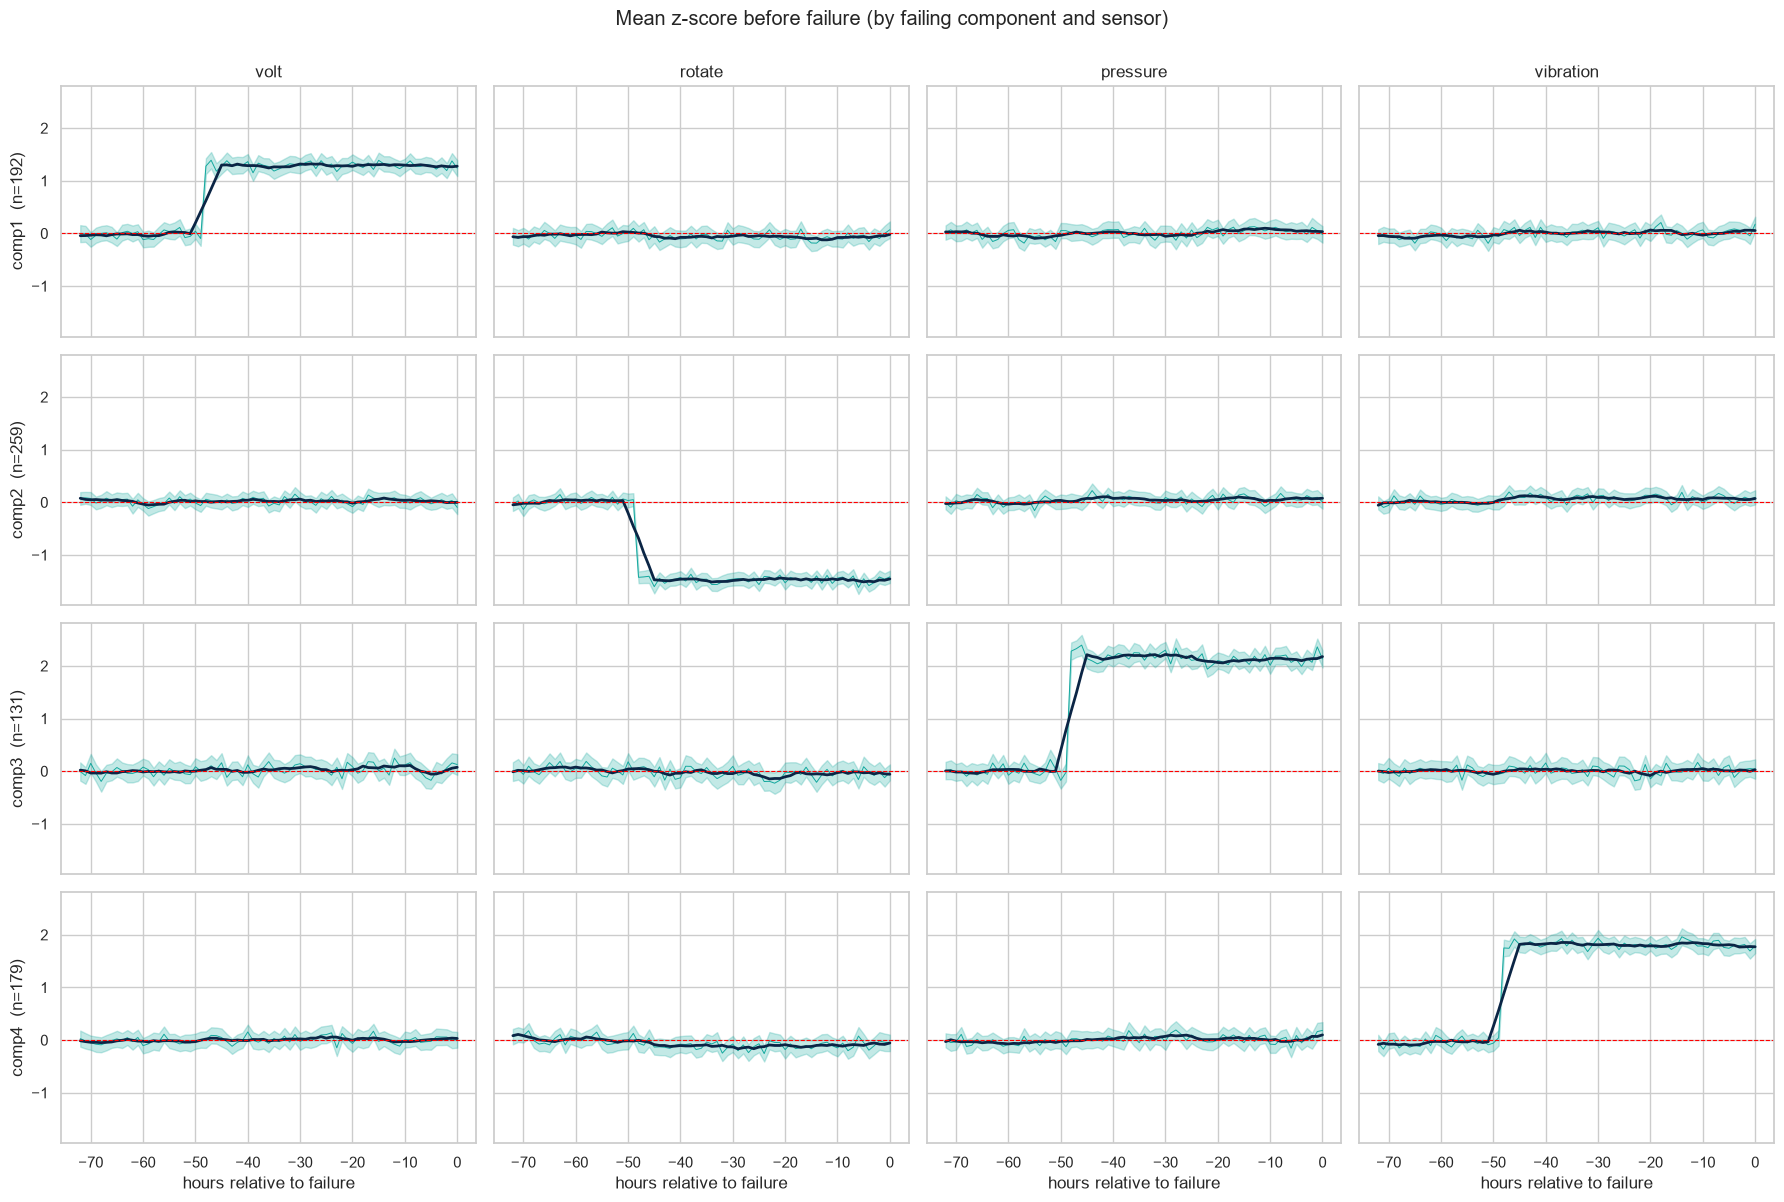

In [12]:
# ------------------------------------------------------------------
# Step 5c: Average z-score curve before failure, by failing component
# (rows) and by sensor (columns). The shaded band is +/- 2 standard
# errors: if the curve leaves the band around 0, the shift is unlikely
# to be chance. The bold line is a 6-hour moving average.
# ------------------------------------------------------------------
fig, axes = plt.subplots(4, 4, figsize=(18, 12), sharex=True, sharey=True)
for i, comp in enumerate(COMPS):
    mask = (fk["failure"] == comp).values
    for j, s in enumerate(SENSORS):
        A = Z[s][mask]
        mean = np.nanmean(A, axis=0)
        se = np.nanstd(A, axis=0) / np.sqrt(np.sum(~np.isnan(A), axis=0))
        ax = axes[i, j]
        ax.fill_between(offsets, mean - 2 * se, mean + 2 * se, color="#13A89E", alpha=0.25)
        ax.plot(offsets, mean, lw=0.7, color="#13A89E")
        ax.plot(offsets, pd.Series(mean).rolling(6, center=True, min_periods=1).mean(), lw=2, color="#0B2545")
        ax.axhline(0, color="red", ls="--", lw=0.8)
        if i == 0:
            ax.set_title(s)
        if j == 0:
            ax.set_ylabel(f"{comp}  (n={mask.sum()})")
        if i == 3:
            ax.set_xlabel("hours relative to failure")
plt.suptitle("Mean z-score before failure (by failing component and sensor)", y=1.0)
plt.tight_layout()
savefig("03_pre_failure_curves")
plt.show()

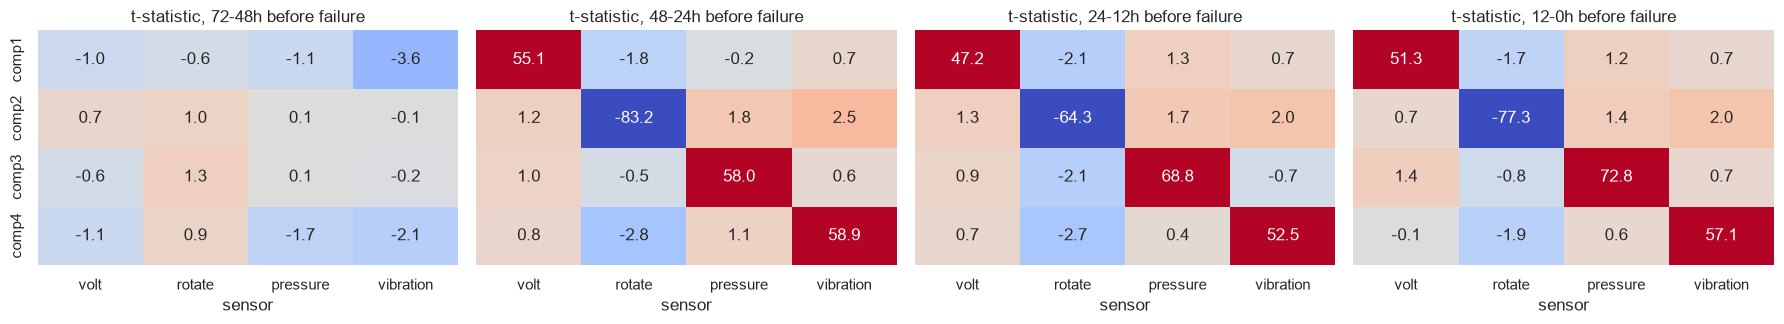

Significant shifts (|t| > 3 and |mean z| >= 0.15):


,comp,sensor,block,start_h,mean_z,se,t,n
0,comp2,rotate,48-24h,48,-1.478,0.018,-83.235,256
1,comp2,rotate,12-0h,12,-1.473,0.019,-77.252,259
2,comp3,pressure,12-0h,12,2.135,0.029,72.770,131
3,comp3,pressure,24-12h,24,2.094,0.030,68.837,131
4,comp2,rotate,24-12h,24,-1.456,0.023,-64.296,259
5,comp4,vibration,48-24h,48,1.820,0.031,58.913,176
6,comp3,pressure,48-24h,48,2.194,0.038,57.972,127
7,comp4,vibration,12-0h,12,1.797,0.031,57.105,179
8,comp1,volt,48-24h,48,1.291,0.023,55.150,181
9,comp4,vibration,24-12h,24,1.811,0.035,52.477,179


In [13]:
# ------------------------------------------------------------------
# Step 5d: Quantify the shift in time blocks.
# For each failure we average the z-score inside a block of hours,
# then test whether the mean over failures differs from 0:
#   t = mean / standard_error.  |t| > 3 is unlikely to be chance
# (64 tests are made, so about 0.2 false alarms are expected).
# With ~100-250 failures per component a tiny shift can reach |t| > 3,
# so we ALSO require a practically meaningful size: |mean z| >= 0.15.
# ------------------------------------------------------------------
BLOCKS = [("72-48h", 72, slice(0, 24)),
          ("48-24h", 48, slice(24, 48)),
          ("24-12h", 24, slice(48, 60)),
          ("12-0h", 12, slice(60, 73))]          # slices on the 73-column offset axis

res = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)   # all-NaN rows are expected for early failures
    for comp in COMPS:
        mask = (fk["failure"] == comp).values
        for s in SENSORS:
            for label, start_h, sl in BLOCKS:
                per_failure = np.nanmean(Z[s][mask][:, sl], axis=1)
                per_failure = per_failure[~np.isnan(per_failure)]
                mean = per_failure.mean()
                se = per_failure.std(ddof=1) / np.sqrt(len(per_failure))
                res.append({"comp": comp, "sensor": s, "block": label, "start_h": start_h,
                            "mean_z": mean, "se": se, "t": mean / se, "n": len(per_failure)})
res = pd.DataFrame(res)

fig, axes = plt.subplots(1, 4, figsize=(18, 3.4), sharey=True)
for ax, (label, _, _) in zip(axes, BLOCKS):
    piv = res[res["block"] == label].pivot(index="comp", columns="sensor", values="t")[SENSORS]
    sns.heatmap(piv, annot=True, fmt=".1f", cmap="coolwarm", center=0, vmin=-8, vmax=8, ax=ax, cbar=False)
    ax.set_title(f"t-statistic, {label} before failure")
    ax.set_ylabel("")
plt.tight_layout()
savefig("03_pre_failure_tstats")
plt.show()

sig = res[(res["t"].abs() > 3) & (res["mean_z"].abs() >= 0.15)]
print("Significant shifts (|t| > 3 and |mean z| >= 0.15):")
display(sig.round(3).sort_values("t", key=abs, ascending=False).reset_index(drop=True))

In [14]:
# ------------------------------------------------------------------
# Step 5e: Does the VARIABILITY change before a failure?
# We compare the standard deviation of the z-scores in the 24 h
# before the failure with the normal value (1.0 by construction).
# A ratio above 1 means the sensor becomes more erratic.
# ------------------------------------------------------------------
rows_std = []
for comp in COMPS:
    mask = (fk["failure"] == comp).values
    rows_std.append({"comp": comp, **{s: round(float(np.nanstd(Z[s][mask][:, H - 24:])), 3) for s in SENSORS}})
print("Std of z-score in the 24 h before failure (1.0 = normal):")
display(pd.DataFrame(rows_std).set_index("comp"))

Std of z-score in the 24 h before failure (1.0 = normal):


,volt,rotate,pressure,vibration
comp,,,,
comp1,1.003,1.039,1.082,1.032
comp2,1.012,0.969,1.055,1.079
comp3,1.051,1.038,0.914,0.991
comp4,1.025,1.069,1.049,0.989


## Step 6 - Define the `natural_failure` window
The window length is chosen from the data (Step 5), not arbitrarily. If no precursor signal is found in the telemetry, we fall back to 48 h, which is the usual horizon in predictive maintenance, and we say so in the report.

In [15]:
# ------------------------------------------------------------------
# Step 6a: Choose the pre-failure window length.
# Rule: take the farthest time block that shows a significant shift
# (|t| > 3 and |mean z| >= 0.15, table "sig" of Step 5d).
# If nothing is significant, use 48 h.
# You can override PRE_WINDOW_H by hand if you disagree with the
# result, but then document the reason in the report.
# ------------------------------------------------------------------
if len(sig):
    PRE_WINDOW_H = int(sig["start_h"].max())
    reason = f"farthest significant block starts {PRE_WINDOW_H} h before failure"
else:
    PRE_WINDOW_H = 48
    reason = "no significant precursor in telemetry; default 48 h horizon"
print("PRE_WINDOW_H =", PRE_WINDOW_H, "|", reason)

PRE_WINDOW_H = 48 | farthest significant block starts 48 h before failure


In [16]:
# ------------------------------------------------------------------
# Step 6b: Create the ground-truth labels at hourly resolution.
# For each failure, the PRE_WINDOW_H hours before it (and the
# failure hour itself) get label_natural_failure = 1.
# - hours_to_failure : distance to the NEXT failure (0 = failure hour)
# - failing_comp     : which component fails
# When two windows overlap, the nearest failure wins.
# ------------------------------------------------------------------
n = len(tel)
label = np.zeros(n, dtype=np.int8)
hours_to = np.full(n, np.nan)
comp_arr = np.full(n, "", dtype=object)
start_of = tel.groupby("machineID")["row"].min().to_dict()   # first row of each machine

for r, m_id, comp in zip(fk["row"].values, fk["machineID"].values, fk["failure"].values):
    lo = max(r - PRE_WINDOW_H, start_of[m_id])               # never cross into the previous machine
    idx = np.arange(lo, r + 1)
    new_h = (r - idx).astype(float)
    cur = hours_to[lo:r + 1]                                  # view on the original array
    better = np.isnan(cur) | (new_h < cur)
    cur[better] = new_h[better]
    label[lo:r + 1] = 1
    c_view = comp_arr[lo:r + 1]
    c_view[better] = comp

labels = tel[["machineID", "datetime"]].copy()
labels["label_natural_failure"] = label
labels["hours_to_failure"] = hours_to
labels["failing_comp"] = comp_arr

print(f"Rows labelled natural_failure: {label.sum():,} ({label.mean():.2%} of all hours)")
print("\nLabelled hours by failing component:")
print(labels.loc[labels["label_natural_failure"] == 1, "failing_comp"].value_counts().sort_index().to_string())

Rows labelled natural_failure: 34,678 (3.96% of all hours)

Labelled hours by failing component:
failing_comp
comp1     9117
comp2    12169
comp3     5878
comp4     7514


## Step 7 - Save outputs and summary

In [17]:
# ------------------------------------------------------------------
# Step 7a: Save the results for the next notebooks.
# - natural_failure_labels : hourly ground truth (used in 05 and 06)
# - failures_enriched.csv  : failures with a flag "error in last 72 h"
# - maint_classified.csv   : maintenance with corrective/preventive type
# - logs/phase1_params.json: the chosen parameters (reproducibility)
# ------------------------------------------------------------------
PROCESSED.mkdir(parents=True, exist_ok=True)
try:
    labels.to_parquet(PROCESSED / "natural_failure_labels.parquet", index=False)
    saved = "parquet"
except Exception as e:
    labels.to_pickle(PROCESSED / "natural_failure_labels.pkl")
    saved = f"pickle (parquet unavailable: {type(e).__name__})"

fail_enriched = fail.copy()
fail_enriched["error_in_last_72h"] = fail_enriched.index.isin(pre["fid"].unique()).astype(int)
fail_enriched.to_csv(PROCESSED / "failures_enriched.csv", index=False)
mnt_c.to_csv(PROCESSED / "maint_classified.csv", index=False)

params = {"PRE_WINDOW_H": PRE_WINDOW_H, "reason": reason, "SEED": SEED,
          "significant_blocks": int(len(sig))}
(LOGS / "phase1_params.json").write_text(json.dumps(params, indent=2), encoding="utf-8")
print("Saved labels as", saved, "| parameters:", params)

Saved labels as parquet | parameters: {'PRE_WINDOW_H': 48, 'reason': 'farthest significant block starts 48 h before failure', 'SEED': 42, 'significant_blocks': 12}


In [18]:
# ------------------------------------------------------------------
# Step 7b: Compact summary of the findings of this notebook.
# These numbers go into the project proposal (data exploration part).
# ------------------------------------------------------------------
summary = {
    "failures": int(len(fail)),
    "machines with 0 failures": int((n_fail == 0).sum()),
    "corr(age, n_failures)": round(float(np.corrcoef(md["age"], md["n_fail"])[0, 1]), 3),
    "failures preceded by an error (72 h)": f"{pre['fid'].nunique() / len(fail):.1%}",
    "corrective maintenance share": f"{mnt_c['corrective'].mean():.1%}",
    "significant telemetry shifts": int(len(sig)),
    "PRE_WINDOW_H": PRE_WINDOW_H,
    "share of hours labelled natural_failure": f"{label.mean():.2%}",
}
display(pd.Series(summary, name="value").to_frame())

,value
failures,761
machines with 0 failures,2
"corr(age, n_failures)",0.466
failures preceded by an error (72 h),98.0%
corrective maintenance share,22.6%
significant telemetry shifts,12
PRE_WINDOW_H,48
share of hours labelled natural_failure,3.96%
